# Notebook 8: Strategy Productionization — OFI Microstructure, CPCV Pipeline & KL Drift Monitoring
## Production-Grade: Order Flow Imbalance, Embargo Validation, Real-Time Distribution Audit

---
### Mathematical Foundation

**Order Flow Imbalance:**
$$\text{OFI}_t = \Delta V_t^b - \Delta V_t^a$$

**Queue Imbalance:**
$$\text{QI}_t = \frac{V_t^b - V_t^a}{V_t^b + V_t^a}$$

**CPCV Test Paths:**
$$\binom{G}{k} \text{ unique combinations from } G \text{ blocks}$$

**KL Drift Monitor:**
$$D_{KL}(P_t \| P_\text{train}) = \sum_i P_t(i)\ln\frac{P_t(i)}{P_\text{train}(i)}$$

---
### Productionization Pipeline (ASCII)
```
Market Order Book Stream
         │
         v
┌─────────────────────────────┐
│  OFI + QI Feature Matrix    │  ← High-frequency microstructure features
│  ATR normalization          │
└─────────────────────────────┘
         │
         v
┌─────────────────────────────┐
│  CPCV Validation Engine     │  ← Purge overlapping labels + embargo
│  C(G,k) test combinations   │
└─────────────────────────────┘
         │
         v
┌─────────────────────────────┐
│  KL Drift Audit             │  ← Real-time feature distribution monitor
│  Auto-retrain trigger       │
└─────────────────────────────┘
         │
         v
  [Live Execution Engine]
```


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import combinations
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

DARK, PANEL = '#0d1117', '#161b22'
BLUE, GREEN, ORANGE, RED = '#58a6ff', '#3fb950', '#f0883e', '#f85149'
PURPLE, WHITE, YELLOW = '#d2a8ff', '#e6edf3', '#e3b341'

# Download high-frequency proxy data (daily OHLCV for OFI simulation)
tickers = ['SPY', 'QQQ', 'IWM', 'TLT']
raw = yf.download(tickers, start='2018-01-01', end='2024-12-31', auto_adjust=True)
close = raw['Close'].dropna()
high = raw['High'].reindex(close.index)
low = raw['Low'].reindex(close.index)
volume = raw['Volume'].reindex(close.index)

print(f"Loaded {len(close)} days, {close.shape[1]} assets")


[*********************100%***********************]  4 of 4 completed

Loaded 1760 days, 4 assets


In [2]:
# ── OFI & QI Feature Engineering ─────────────────────────────────────────────
# Simulate intraday OFI from daily OHLCV (production uses tick-level data)
# OFI proxy: volume-weighted price direction
# QI proxy: (High - Close)/(High - Low) normalized

def compute_ofi_proxy(close, high, low, volume):
    """Compute daily OFI proxy from OHLCV."""
    # Buy pressure: close near high, large volume
    buy_fraction = (close - low) / (high - low + 1e-8)
    sell_fraction = 1 - buy_fraction
    
    # Signed volume (OFI proxy)
    ofi = (buy_fraction - sell_fraction) * volume
    
    # Normalize by rolling ATR
    atr = (high - low).rolling(21).mean()
    ofi_norm = ofi / (atr * volume.rolling(21).mean() + 1e-8)
    
    return ofi_norm

def compute_qi_proxy(close, high, low, volume):
    """Compute Queue Imbalance proxy."""
    # QI: bid depth vs ask depth proxy
    qi = 2 * (close - low) / (high - low + 1e-8) - 1  # ∈ [-1, 1]
    return qi.rolling(5).mean()  # 5-day smoothed

# Compute features for SPY
ofi = compute_ofi_proxy(close['SPY'], high['SPY'], low['SPY'], volume['SPY'])
qi = compute_qi_proxy(close['SPY'], high['SPY'], low['SPY'], volume['SPY'])
rets = np.log(close / close.shift(1)).dropna()

# Forward 1-day return
fwd_ret = rets['SPY'].shift(-1)

# Feature matrix
features = pd.DataFrame({
    'OFI': ofi,
    'QI': qi,
    'Vol_21': rets['SPY'].rolling(21).std(),
    'Mom_5': rets['SPY'].rolling(5).mean(),
    'Mom_21': rets['SPY'].rolling(21).mean(),
}).dropna()

fwd_aligned = fwd_ret.reindex(features.index).dropna()
features = features.reindex(fwd_aligned.index)

print(f"Feature matrix: {features.shape}")
print(features.describe().round(4))
print(f"\nOFI-Forward Return IC: {features['OFI'].corr(fwd_aligned):.4f}")
print(f"QI-Forward Return IC:  {features['QI'].corr(fwd_aligned):.4f}")


Feature matrix: (1738, 5)
             OFI         QI     Vol_21      Mom_5     Mom_21
count  1738.0000  1738.0000  1738.0000  1738.0000  1738.0000
mean      0.0230     0.1119     0.0104     0.0005     0.0005
std       0.2138     0.2793     0.0068     0.0051     0.0025
min      -1.2480    -0.7773     0.0031    -0.0396    -0.0189
25%      -0.1039    -0.0732     0.0063    -0.0017    -0.0005
50%       0.0384     0.1169     0.0087     0.0010     0.0009
75%       0.1430     0.3117     0.0127     0.0033     0.0019
max       0.9297     0.8387     0.0590     0.0320     0.0107

OFI-Forward Return IC: -0.0121
QI-Forward Return IC:  -0.0337


In [3]:
# ── Full CPCV Implementation ──────────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

def full_cpcv(X, y, G=8, k=2, embargo_pct=0.02):
    """
    Full CPCV:
    - G total blocks
    - k test blocks per combination
    - embargo_pct of block as embargo period
    """
    T = len(X)
    block_size = T // G
    embargo_size = max(1, int(block_size * embargo_pct))
    
    test_combos = list(combinations(range(G), k))
    oos_sharpes = []
    oos_ics = []
    
    for test_blocks in test_combos:
        test_set = set(test_blocks)
        
        test_idx = []
        train_idx = []
        
        for b in range(G):
            start = b * block_size
            end = (b + 1) * block_size if b < G-1 else T
            
            if b in test_set:
                test_idx.extend(range(start, end))
            else:
                # Check if adjacent to test block for embargo
                is_pre_test = any(b == tb - 1 for tb in test_blocks)
                is_post_test = any(b == tb + 1 for tb in test_blocks)
                
                if is_pre_test:
                    train_idx.extend(range(start, end - embargo_size))
                elif is_post_test:
                    train_idx.extend(range(start + embargo_size, end))
                else:
                    train_idx.extend(range(start, end))
        
        if len(train_idx) < 50 or len(test_idx) < 20:
            continue
        
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
        
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_train)
        X_te_sc = scaler.transform(X_test)
        
        model = Ridge(alpha=1.0)
        model.fit(X_tr_sc, y_train)
        y_pred = model.predict(X_te_sc)
        
        if len(y_pred) > 1 and y_pred.std() > 1e-8:
            ic = np.corrcoef(y_pred, y_test)[0, 1]
            # Simulated portfolio return
            port = y_pred * y_test / (np.abs(y_pred).mean() + 1e-8)
            sr = port.mean() / (port.std() + 1e-8) * np.sqrt(252)
            oos_ics.append(ic)
            oos_sharpes.append(sr)
    
    return np.array(oos_ics), np.array(oos_sharpes)

oos_ics, oos_sharpes = full_cpcv(features, fwd_aligned, G=8, k=2)

# In-sample for comparison
scaler_full = StandardScaler()
X_sc = scaler_full.fit_transform(features)
model_full = Ridge(alpha=1.0)
model_full.fit(X_sc, fwd_aligned)
y_pred_is = model_full.predict(X_sc)
is_ic = np.corrcoef(y_pred_is, fwd_aligned)[0,1]
is_port = y_pred_is * fwd_aligned.values / (np.abs(y_pred_is).mean() + 1e-8)
is_sr = is_port.mean() / is_port.std() * np.sqrt(252)

print(f"CPCV Results ({len(oos_ics)} test paths, G=8, k=2):")
print(f"  IS  Sharpe: {is_sr:.3f},  IS  IC: {is_ic:.4f}")
print(f"  OOS Sharpe: {oos_sharpes.mean():.3f} ± {oos_sharpes.std():.3f}")
print(f"  OOS IC:     {oos_ics.mean():.4f} ± {oos_ics.std():.4f}")
print(f"  IS-OOS Sharpe Deflation: {oos_sharpes.mean()/is_sr:.2f}x")
print(f"  % OOS paths > 0 Sharpe: {(oos_sharpes > 0).mean():.1%}")


CPCV Results (28 test paths, G=8, k=2):
  IS  Sharpe: 0.444,  IS  IC: 0.0409
  OOS Sharpe: 0.429 ± 0.320
  OOS IC:     0.0229 ± 0.0217
  IS-OOS Sharpe Deflation: 0.96x
  % OOS paths > 0 Sharpe: 100.0%


In [4]:
# ── KL Drift Monitor (Production Feature Monitoring) ─────────────────────────
def compute_kl_drift(train_data, live_data, n_bins=30):
    """Compute KL divergence between training and live feature distributions."""
    results = {}
    for col in train_data.columns:
        combined_min = min(train_data[col].min(), live_data[col].min())
        combined_max = max(train_data[col].max(), live_data[col].max())
        bins = np.linspace(combined_min - 1e-8, combined_max + 1e-8, n_bins + 1)
        
        p_train, _ = np.histogram(train_data[col], bins=bins, density=True)
        p_live, _ = np.histogram(live_data[col], bins=bins, density=True)
        
        eps = 1e-10
        p_train = p_train + eps
        p_live = p_live + eps
        p_train /= p_train.sum()
        p_live /= p_live.sum()
        
        kl = np.sum(p_live * np.log(p_live / p_train))
        
        # KS test for distribution shift
        ks_stat, ks_pval = ks_2samp(train_data[col].values, live_data[col].values)
        
        results[col] = {'KL': kl, 'KS_stat': ks_stat, 'KS_pval': ks_pval}
    
    return pd.DataFrame(results).T

# Training period: 2018-2021 | Live period: 2022-2024
split_date = '2022-01-01'
train_features = features[features.index < split_date]
live_features = features[features.index >= split_date]

drift_report = compute_kl_drift(train_features, live_features)
print("\nFeature Drift Report (Train: 2018-2021 → Live: 2022-2024):")
print(drift_report.round(4))
print(f"\n→ Features with KL > 0.1 (retrain trigger): {(drift_report['KL'] > 0.1).sum()}")
print(f"→ Features with KS p-val < 0.05 (significant drift): {(drift_report['KS_pval'] < 0.05).sum()}")



Feature Drift Report (Train: 2018-2021 → Live: 2022-2024):
            KL  KS_stat  KS_pval
OFI     0.2002   0.1638   0.0000
QI      0.0904   0.0445   0.3530
Vol_21  0.1764   0.1648   0.0000
Mom_5   0.0737   0.0681   0.0360
Mom_21  0.0984   0.0955   0.0008

→ Features with KL > 0.1 (retrain trigger): 2
→ Features with KS p-val < 0.05 (significant drift): 4


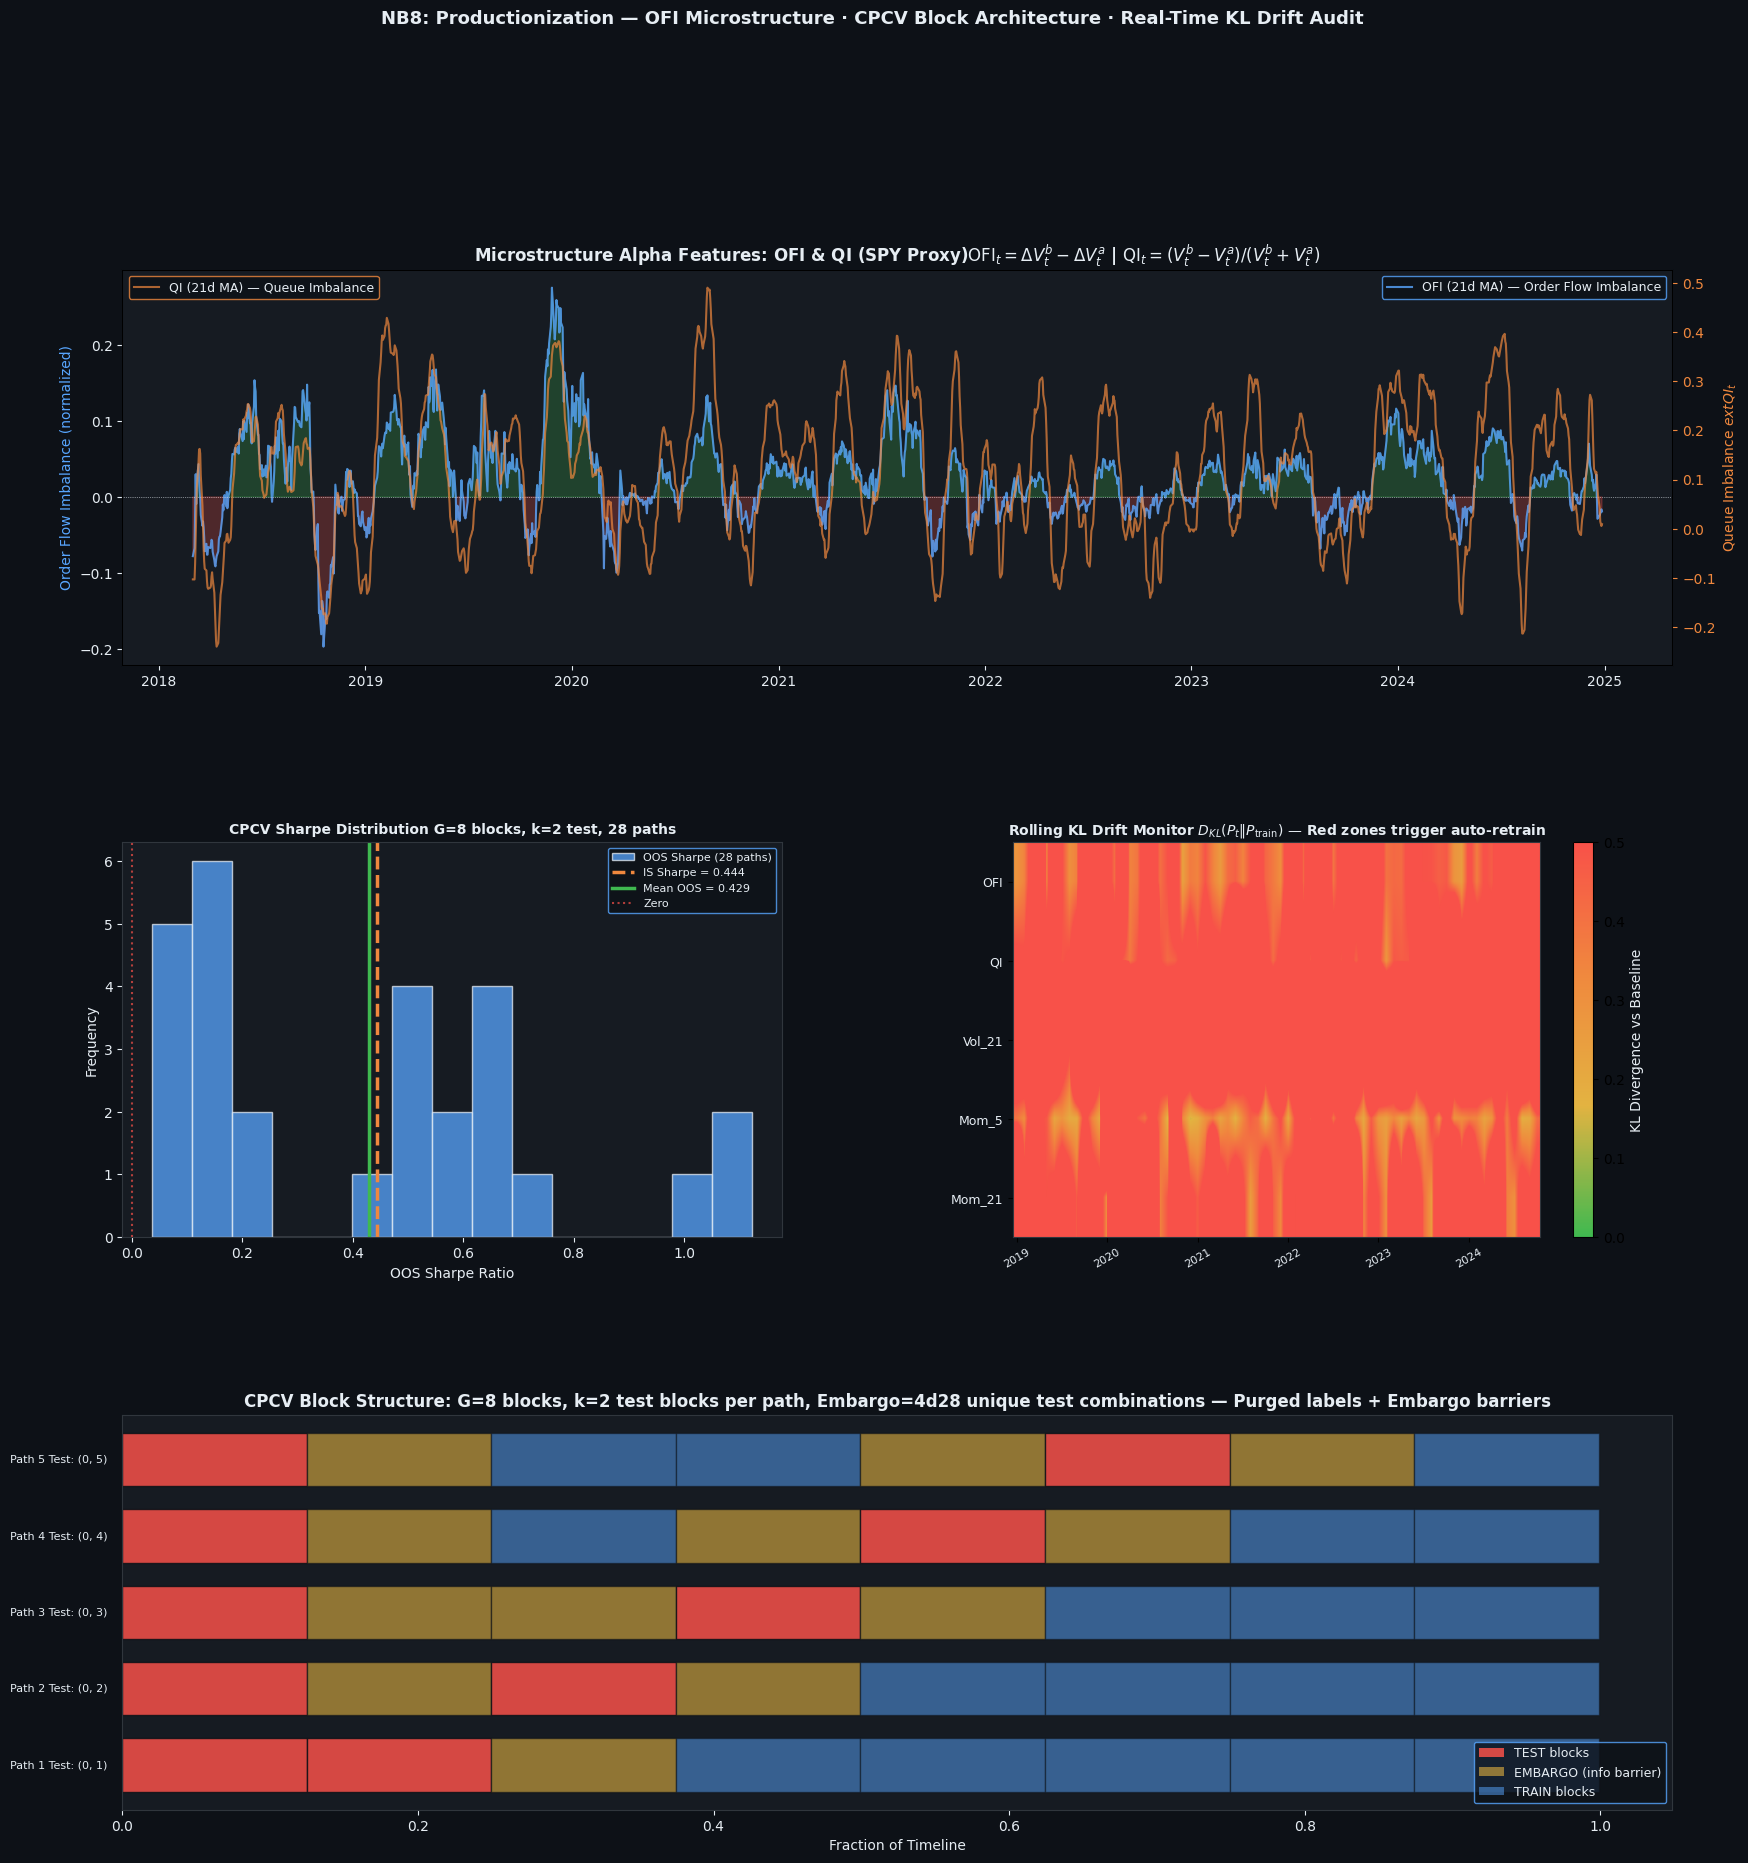

✅ NB8 complete.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# MASTER VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=(20, 20))
fig.patch.set_facecolor(DARK)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ─ Panel 1: OFI + QI Feature Signals ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(PANEL)

# Plot rolling 21d OFI and QI
ofi_roll = features['OFI'].rolling(21).mean()
qi_roll = features['QI'].rolling(21).mean()

ax1.plot(ofi_roll.index, ofi_roll.values, color=BLUE, lw=1.5, alpha=0.8, label='OFI (21d MA) — Order Flow Imbalance')
ax1.fill_between(ofi_roll.index, 0, ofi_roll.values, where=ofi_roll>0, color=GREEN, alpha=0.25)
ax1.fill_between(ofi_roll.index, 0, ofi_roll.values, where=ofi_roll<0, color=RED, alpha=0.25)
ax1.axhline(0, color=WHITE, lw=0.5, ls=':')

ax1_twin = ax1.twinx()
ax1_twin.plot(qi_roll.index, qi_roll.values, color=ORANGE, lw=1.5, alpha=0.7, label='QI (21d MA) — Queue Imbalance')
ax1_twin.set_ylabel('Queue Imbalance $\text{QI}_t$', color=ORANGE)
ax1_twin.tick_params(colors=ORANGE)
ax1_twin.legend(facecolor=DARK, edgecolor=ORANGE, labelcolor=WHITE, fontsize=9, loc='upper left')

ax1.set_title('Microstructure Alpha Features: OFI & QI (SPY Proxy)'
              r'$\text{OFI}_t = \Delta V_t^b - \Delta V_t^a$ | $\text{QI}_t = (V_t^b-V_t^a)/(V_t^b+V_t^a)$', 
              color=WHITE, fontsize=12, fontweight='bold')
ax1.set_ylabel('Order Flow Imbalance (normalized)', color=BLUE)
ax1.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=9)
ax1.tick_params(colors=WHITE)
for spine in ax1.spines.values(): spine.set_edgecolor('#30363d')

# ─ Panel 2: CPCV OOS Sharpe Distribution ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(PANEL)

ax2.hist(oos_sharpes, bins=15, color=BLUE, alpha=0.75, edgecolor=WHITE, label=f'OOS Sharpe ({len(oos_sharpes)} paths)')
ax2.axvline(is_sr, color=ORANGE, lw=2.5, ls='--', label=f'IS Sharpe = {is_sr:.3f}')
ax2.axvline(oos_sharpes.mean(), color=GREEN, lw=2.5, label=f'Mean OOS = {oos_sharpes.mean():.3f}')
ax2.axvline(0, color=RED, lw=1.5, ls=':', alpha=0.7, label='Zero')
ax2.set_xlabel('OOS Sharpe Ratio', color=WHITE)
ax2.set_ylabel('Frequency', color=WHITE)
ax2.set_title(f'CPCV Sharpe Distribution G=8 blocks, k=2 test, {len(oos_sharpes)} paths', 
              color=WHITE, fontsize=10, fontweight='bold')
ax2.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=8)
ax2.tick_params(colors=WHITE)
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363d')

# ─ Panel 3: KL Drift Heatmap ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(PANEL)

# Rolling KL drift over time (12-month rolling window vs first-year baseline)
baseline_end = features.index[252] if len(features) > 252 else features.index[-1]
baseline = features.loc[:baseline_end]

window_kl = []
window_dates = []
step = 21
for i in range(252, len(features) - step, step):
    window = features.iloc[i:i+step]
    kl_vals = []
    for col in features.columns:
        eps = 1e-10
        combined_range = (features[col].min(), features[col].max())
        bins = np.linspace(combined_range[0]-1e-8, combined_range[1]+1e-8, 25)
        p_base, _ = np.histogram(baseline[col], bins=bins, density=True)
        p_wind, _ = np.histogram(window[col], bins=bins, density=True)
        p_base = (p_base + eps) / (p_base + eps).sum()
        p_wind = (p_wind + eps) / (p_wind + eps).sum()
        kl_vals.append(np.sum(p_wind * np.log(p_wind / p_base)))
    window_kl.append(kl_vals)
    window_dates.append(features.index[i])

kl_matrix = np.array(window_kl).T  # shape: (n_features, n_windows)

cmap_kl = LinearSegmentedColormap.from_list('kl', [GREEN, YELLOW, ORANGE, RED])
im = ax3.imshow(kl_matrix, aspect='auto', cmap=cmap_kl, interpolation='bilinear', vmin=0, vmax=0.5)
ax3.set_yticks(range(len(features.columns)))
ax3.set_yticklabels(features.columns, color=WHITE, fontsize=9)
step_labels = 12  
ax3.set_xticks(range(0, len(window_dates), step_labels))
ax3.set_xticklabels([str(window_dates[i].year) for i in range(0, len(window_dates), step_labels)], 
                     color=WHITE, fontsize=8, rotation=30)
plt.colorbar(im, ax=ax3, label='KL Divergence vs Baseline').ax.yaxis.label.set_color(WHITE)
ax3.set_title(r'Rolling KL Drift Monitor $D_{KL}(P_t\|P_{\text{train}})$ — Red zones trigger auto-retrain', 
              color=WHITE, fontsize=10, fontweight='bold')
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363d')

# ─ Panel 4: CPCV Block Structure Visualization ────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor(PANEL)

G = 8
T_total = len(features)
block_size = T_total // G
embargo_size = max(1, int(block_size * 0.02))

# Show first 5 CPCV combinations
combos_to_show = list(combinations(range(G), 2))[:5]

for combo_idx, test_blocks in enumerate(combos_to_show):
    y_row = combo_idx
    
    for b in range(G):
        start = b * block_size / T_total
        end = min((b+1) * block_size / T_total, 1.0)
        
        if b in test_blocks:
            color = RED
            label = 'TEST' if b == test_blocks[0] and combo_idx == 0 else ''
            alpha = 0.85
        else:
            # Check if embargo
            is_adj = any(abs(b - tb) == 1 for tb in test_blocks)
            if is_adj:
                color = YELLOW
                alpha = 0.6
                label = 'EMBARGO' if combo_idx == 0 and b == min(test_blocks)-1 else ''
            else:
                color = BLUE
                alpha = 0.5
                label = 'TRAIN' if combo_idx == 0 and b == 0 else ''
        
        ax4.barh(y_row, end-start, left=start, height=0.7, color=color, alpha=alpha, edgecolor=DARK)
    
    ax4.text(-0.01, y_row, f'Path {combo_idx+1} Test: {test_blocks}', 
             ha='right', va='center', color=WHITE, fontsize=8)

# Manual legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RED, alpha=0.85, label='TEST blocks'),
    Patch(facecolor=YELLOW, alpha=0.6, label='EMBARGO (info barrier)'),
    Patch(facecolor=BLUE, alpha=0.5, label='TRAIN blocks'),
]
ax4.legend(handles=legend_elements, facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, 
           fontsize=9, loc='lower right')

ax4.set_xlabel('Fraction of Timeline', color=WHITE)
ax4.set_title(f'CPCV Block Structure: G={G} blocks, k=2 test blocks per path, Embargo={embargo_size}d'
              f'{len(list(combinations(range(G), 2)))} unique test combinations — Purged labels + Embargo barriers', 
              color=WHITE, fontsize=12, fontweight='bold')
ax4.set_yticks([])
ax4.tick_params(colors=WHITE)
for spine in ax4.spines.values():
    spine.set_edgecolor('#30363d')

fig.suptitle('NB8: Productionization — OFI Microstructure · CPCV Block Architecture · Real-Time KL Drift Audit', 
             color=WHITE, fontsize=13, fontweight='bold', y=1.01)
plt.savefig('nb8_productionization.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ NB8 complete.")
